In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# --- Global Configurations ---
# Keeping the test/val split logic in mind for later (60/20/20)
RANDOM_STATE = 42
plt.style.use('ggplot') # Or 'seaborn-v0_8' to match his plots
sns.set_theme(style="whitegrid")

# Path management
DATA_DIR = Path("../data")
RAW_DATA_PATH = DATA_DIR / "twcs.csv"
GRAPHS_DIR = Path("../graphs")

# Create graphs directory if it doesn't exist
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Setup complete. Project root: {Path.cwd().parent}")

Setup complete. Project root: /home/bmislol/VSCode/decision-intelligence-assistant


In [ ]:
# Load a specific subset for iterative development
SUBSET_SIZE = 750000

# We use low_memory=False because Twitter IDs and timestamps can be tricky for pandas to guess
df = pd.read_csv(RAW_DATA_PATH, nrows=SUBSET_SIZE, low_memory=False)

# --- Sanity Check Cell ---
print(f"Initial Load Shape: {df.shape}")
print("-" * 30)
print("Column Data Types:")
print(df.dtypes)
print("-" * 30)
print("Missing Values per Column:")
print(df.isnull().sum())

Initial Load Shape: (750000, 7)
------------------------------
Column Data Types:
tweet_id                     int64
author_id                      str
inbound                       bool
created_at                     str
text                           str
response_tweet_id              str
in_response_to_tweet_id    float64
dtype: object
------------------------------
Missing Values per Column:
tweet_id                        0
author_id                       0
inbound                         0
created_at                      0
text                            0
response_tweet_id          258280
in_response_to_tweet_id    200631
dtype: int64


In [4]:
# Explicitly cast types before logic
print("Converting created_at to datetime...")
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')

# Convert IDs to strings to avoid scientific notation issues
df['tweet_id'] = df['tweet_id'].astype(str)
df['author_id'] = df['author_id'].astype(str)

# --- Sanity Check ---
print(df[['tweet_id', 'created_at']].dtypes)

Converting created_at to datetime...


/tmp/ipykernel_483273/3842419107.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')


tweet_id                      str
created_at    datetime64[us, UTC]
dtype: object


In [5]:
# Define Opening Tickets
tickets_df = df[(df['inbound'] == True) & (df['in_response_to_tweet_id'].isna())].copy()

print(f"Total Customer Opening Tickets: {len(tickets_df)}")
print(f"Percentage of subset that are new tickets: {(len(tickets_df)/SUBSET_SIZE)*100:.2f}%")

Total Customer Opening Tickets: 198321
Percentage of subset that are new tickets: 26.44%


/tmp/ipykernel_483273/3914246088.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.values, y=top_brands.index, palette='viridis')


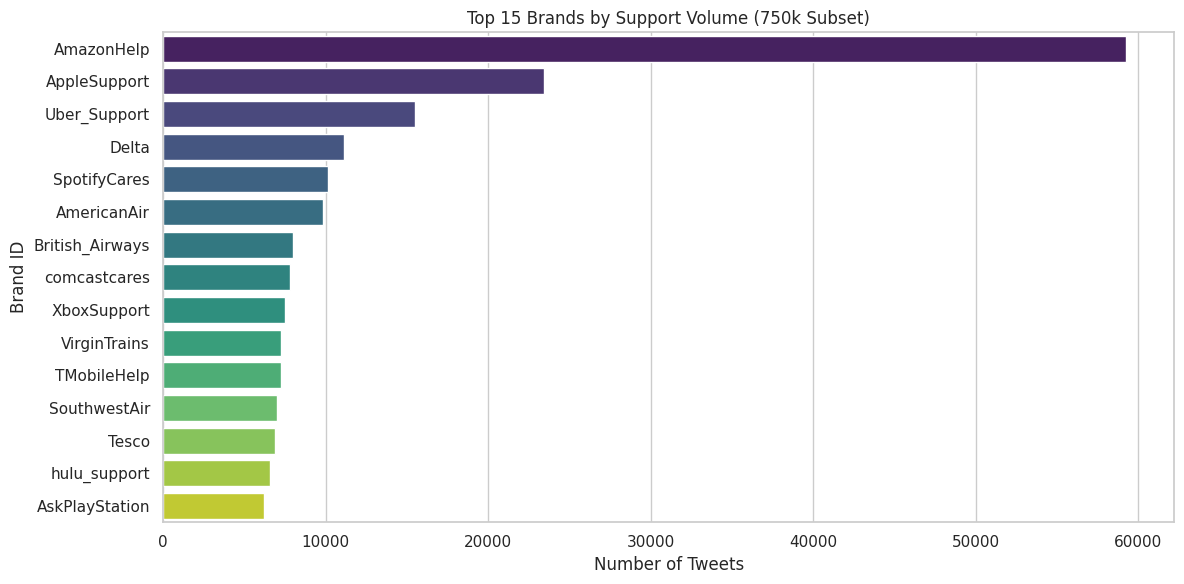

Graph saved to ../graphs/top_brands_distribution.png


In [6]:
# To find brands, we look at who the customers are replying to in the FULL subset
# or who the 'inbound=False' authors are.
top_brands = df[df['inbound'] == False]['author_id'].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_brands.values, y=top_brands.index, palette='viridis')
plt.title("Top 15 Brands by Support Volume (750k Subset)")
plt.xlabel("Number of Tweets")
plt.ylabel("Brand ID")

# Save the artifact
plt.tight_layout()
plt.savefig(GRAPHS_DIR / "top_brands_distribution.png")
plt.show()

print(f"Graph saved to {GRAPHS_DIR / 'top_brands_distribution.png'}")

In [8]:
import re

# --- Modular Preprocessing ---
def clean_tweet_text(text):
    """
    Standardizes tweet text for RAG and ML.
    1. Lowercases
    2. Removes URLs (noise)
    3. Removes @mentions (noise for the issue description)
    4. Fixes whitespace
    """
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply cleaning
print("Cleaning text and engineering NLP features...")
tickets_df['clean_text'] = tickets_df['text'].apply(clean_tweet_text)

# --- Feature Engineering (Day 1: Domain Features) ---
# we create features that might correlate with 'Priority'
tickets_df['text_len'] = tickets_df['clean_text'].str.len()
tickets_df['word_count'] = tickets_df['clean_text'].str.split().str.len()
tickets_df['has_url'] = tickets_df['text'].str.contains('http').astype(int)

# --- Verification Cell ---
print("Cleaning Complete.")
print(tickets_df[['text', 'clean_text', 'text_len']].head())

Cleaning text and engineering NLP features...
Cleaning Complete.
                                                 text  \
6           @sprintcare is the worst customer service   
12  @115714 y’all lie about your “great” connectio...   
14  @115714 whenever I contact customer support, t...   
23  actually that's a broken link you sent me and ...   
25  Yo @Ask_Spectrum, your customer service reps a...   

                                           clean_text  text_len  
6                       is the worst customer service        29  
12  y’all lie about your “great” connection. 5 bar...        85  
14  whenever i contact customer support, they tell...       132  
23  actually that's a broken link you sent me and ...        67  
25  yo , your customer service reps are super nice...       107  


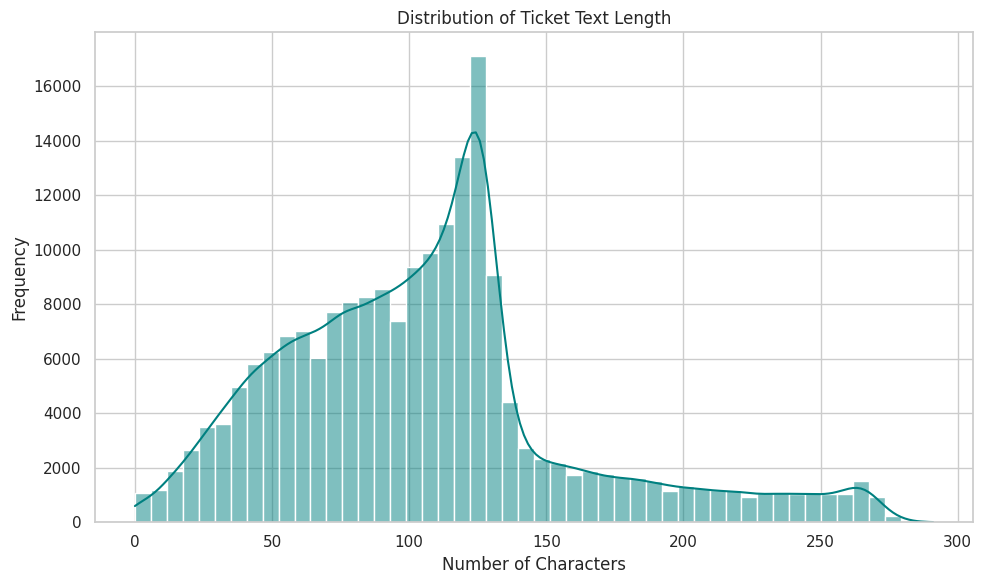

Text Length Summary Statistics:
count    198321.000000
mean        105.882282
std          53.830345
min           0.000000
25%          69.000000
50%         104.000000
75%         127.000000
max         291.000000
Name: text_len, dtype: float64


In [9]:
# Distribution Analysis
plt.figure(figsize=(10, 6))
sns.histplot(tickets_df['text_len'], bins=50, kde=True, color='teal')
plt.title("Distribution of Ticket Text Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

# Save the artifact
plt.tight_layout()
plt.savefig(GRAPHS_DIR / "text_length_distribution.png")
plt.show()

# Quick summary stats
print("Text Length Summary Statistics:")
print(tickets_df['text_len'].describe())

In [10]:
# Quality Filtering (Pruning)
# We remove tickets that are too short to contain a real "Issue"
MIN_CHARS = 10
original_count = len(tickets_df)

tickets_df = tickets_df[tickets_df['text_len'] >= MIN_CHARS].copy()

dropped_count = original_count - len(tickets_df)
print(f"Dropped {dropped_count} low-signal tickets (less than {MIN_CHARS} chars).")
print(f"Final clean ticket count: {len(tickets_df)}")

# --- Verification Check ---
# Let's see a few of the shortest remaining tickets to see if 10 is a good limit
print("\nSample of 'Short' Tickets (Potential Noise Check):")
print(tickets_df.sort_values('text_len')[['clean_text', 'text_len']].head(10))

Dropped 1734 low-signal tickets (less than 10 chars).
Final clean ticket count: 196587

Sample of 'Short' Tickets (Potential Noise Check):
        clean_text  text_len
434617  . gets me.        10
364827  why though        10
568188  answere me        10
484149  any chance        10
548025  add rbd :/        10
270979  tell : don        10
738144  dm'ing you        10
358374  thanks!!!!        10
23859   it's back!        10
291125  please fix        10


Updated Text Length Statistics:
count    196587.000000
mean        106.782275
std          53.202648
min          10.000000
25%          70.000000
50%         104.000000
75%         128.000000
max         291.000000
Name: text_len, dtype: float64


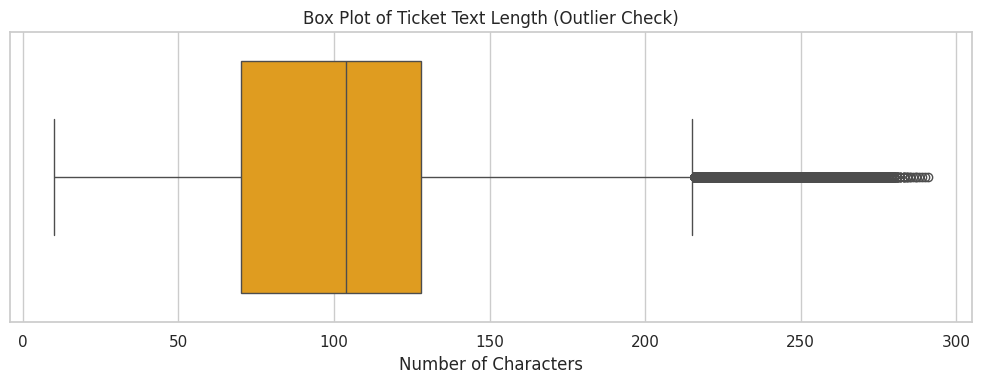

In [11]:
# --- Post-Pruning Sanity Check ---
print("Updated Text Length Statistics:")
print(tickets_df['text_len'].describe())

# --- Visualization: Outlier Detection (Day 3 Logic) ---
plt.figure(figsize=(10, 4))
sns.boxplot(x=tickets_df['text_len'], color='orange')
plt.title("Box Plot of Ticket Text Length (Outlier Check)")
plt.xlabel("Number of Characters")

# Save the artifact
plt.tight_layout()
plt.savefig(GRAPHS_DIR / "text_length_boxplot.png")
plt.show()

Engineering Priority labels...

Priority Distribution (%):
priority
1    70.877525
2    20.528316
0     8.594159
Name: proportion, dtype: float64


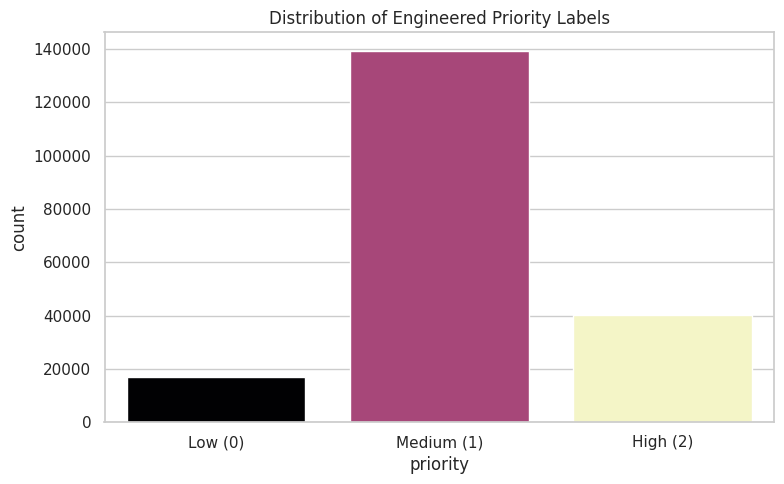

In [12]:
# --- Domain-Based Labeling ---

def assign_priority(text):
    """
    Heuristic to create a target variable 'priority'
    0: Low (Gratitude, general chat)
    1: Medium (Neutral questions, standard issues)
    2: High (Urgent/Negative: broken, worst, error, payment, refund)
    """
    text = text.lower()
    
    # High Priority Keywords
    high_keywords = ['broken', 'worst', 'error', 'cancel', 'refund', 'waiting', 'emergency', 'help', 'fix', 'cannot']
    # Low Priority Keywords
    low_keywords = ['thanks', 'thank', 'awesome', 'great', 'cool', 'love', 'nice']
    
    if any(word in text for word in high_keywords):
        return 2 # High
    if any(word in text for word in low_keywords):
        return 0 # Low
    return 1 # Medium (Default)

print("Engineering Priority labels...")
tickets_df['priority'] = tickets_df['clean_text'].apply(assign_priority)

# --- Sanity Check: Class Distribution ---
priority_counts = tickets_df['priority'].value_counts(normalize=True) * 100
print("\nPriority Distribution (%):")
print(priority_counts)

# Visualization (Instructor Day 2: Checking for Unbalanced Classes)
plt.figure(figsize=(8, 5))
sns.countplot(data=tickets_df, x='priority', palette='magma', hue='priority', legend=False)
plt.title("Distribution of Engineered Priority Labels")
plt.xticks(ticks=[0, 1, 2], labels=['Low (0)', 'Medium (1)', 'High (2)'])

plt.tight_layout()
plt.savefig(GRAPHS_DIR / "priority_distribution.png")
plt.show()

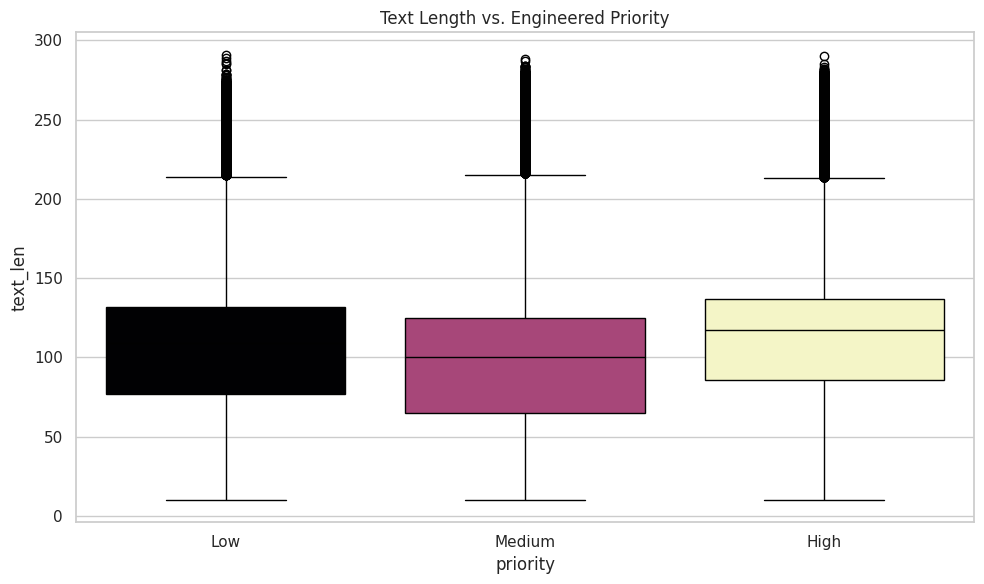

Mean Text Length by Priority:
priority
0    113.481799
1    101.663045
2    121.652542
Name: text_len, dtype: float64


In [14]:
# Correlation Verification
# Does priority relate to how much people write?
plt.figure(figsize=(10, 6))
sns.boxplot(data=tickets_df, x='priority', y='text_len', palette='magma', hue='priority', legend=False)
plt.title("Text Length vs. Engineered Priority")
plt.xticks(ticks=[0, 1, 2], labels=['Low', 'Medium', 'High'])

plt.tight_layout()
plt.savefig(GRAPHS_DIR / "priority_vs_length.png")
plt.show()

# Numeric check
print("Mean Text Length by Priority:")
print(tickets_df.groupby('priority')['text_len'].mean())

In [15]:
# --- Domain Categorization ---

# Map top author_ids to their business sector
tech_brands = ['AppleSupport', 'XboxSupport', 'MicrosoftHelps', 'AdobeCare', 'DellCares']
retail_brands = ['AmazonHelp', 'ArgosHelpers', 'Tesco', 'UPSHelp']
service_brands = ['Uber_Support', 'SpotifyCares', 'AirbnbHelp', 'Delta']

def get_brand_category(author):
    if author in tech_brands:
        return 'Tech'
    if author in retail_brands:
        return 'Retail'
    if author in service_brands:
        return 'Service'
    return 'Other'

# In our current tickets_df, author_id is the customer. 
# To find the BRAND they are talking to, we need to look at who they mention.
# Since we already cleaned the text, we'll look at the original 'text' column.

def extract_brand(text):
    # Quick regex to find mentions like @AppleSupport
    mentions = re.findall(r'@(\w+)', text)
    for m in mentions:
        if m in tech_brands or m in retail_brands or m in service_brands:
            return m
    return 'Unknown'

print("Mapping brands and sectors...")
tickets_df['target_brand'] = tickets_df['text'].apply(extract_brand)
tickets_df['brand_sector'] = tickets_df['target_brand'].apply(get_brand_category)

# --- Final Data Prep Sanity Check ---
print(f"Final Shape: {tickets_df.shape}")
print("\nSector Distribution:")
print(tickets_df['brand_sector'].value_counts())

# Check for Nulls one last time
print("\nNull values in final set:")
print(tickets_df.isnull().sum())

Mapping brands and sectors...
Final Shape: (196587, 14)

Sector Distribution:
brand_sector
Other      153055
Tech        15925
Service     14592
Retail      13015
Name: count, dtype: int64

Null values in final set:
tweet_id                        0
author_id                       0
inbound                         0
created_at                      0
text                            0
response_tweet_id               0
in_response_to_tweet_id    196587
clean_text                      0
text_len                        0
word_count                      0
has_url                         0
priority                        0
target_brand                    0
brand_sector                    0
dtype: int64


In [16]:
# Identifying "Missing Signal"
# Let's see the top 10 brands that are currently labeled as 'Unknown'
unknown_brands = tickets_df[tickets_df['target_brand'] == 'Unknown']['text'].str.extract(r'@(\w+)')[0].value_counts().head(10)

print("Top 10 'Unknown' Brands we should probably categorize:")
print(unknown_brands)

Top 10 'Unknown' Brands we should probably categorize:
0
AmericanAir        5884
115858             4369
115821             4342
SouthwestAir       4296
115850             4162
British_Airways    4086
115873             3581
VirginTrains       3532
ChipotleTweets     3426
AskPlayStation     3256
Name: count, dtype: int64


Engineering temporal signals...
                  created_at  hour_of_day  day_of_week  is_weekend
6  2017-10-31 21:45:10+00:00           21            1           0
12 2017-10-31 19:56:01+00:00           19            1           0
14 2017-10-31 22:03:34+00:00           22            1           0
23 2017-10-31 22:01:35+00:00           22            1           0
25 2017-10-31 22:06:54+00:00           22            1           0


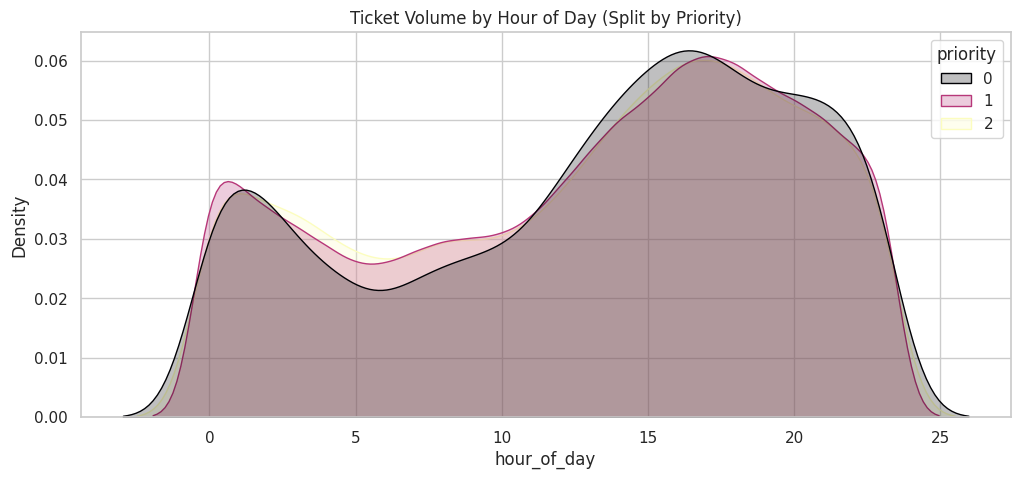

In [17]:
# Temporal Feature Engineering
print("Engineering temporal signals...")

for df_temp in [tickets_df]: # Using his loop pattern
    df_temp['hour_of_day'] = df_temp['created_at'].dt.hour
    df_temp['day_of_week'] = df_temp['created_at'].dt.dayofweek
    # Binary indicator: Is it the weekend? (Day 5 and 6)
    df_temp['is_weekend'] = (df_temp['day_of_week'] >= 5).astype(int)

# --- Sanity Check ---
print(tickets_df[['created_at', 'hour_of_day', 'day_of_week', 'is_weekend']].head())

# Quick visual to see if "High Priority" happens at certain times
plt.figure(figsize=(12, 5))
sns.kdeplot(data=tickets_df, x='hour_of_day', hue='priority', common_norm=False, fill=True, palette='magma')
plt.title("Ticket Volume by Hour of Day (Split by Priority)")
plt.savefig(GRAPHS_DIR / "temporal_priority_density.png")
plt.show()

In [18]:
# Expanding Domain Categories
tech_brands += ['AskPlayStation']
retail_brands += ['ChipotleTweets']
travel_brands = ['AmericanAir', 'SouthwestAir', 'British_Airways', 'VirginTrains']

def get_brand_category_v2(author):
    if author in tech_brands: return 'Tech'
    if author in retail_brands: return 'Retail'
    if author in travel_brands: return 'Travel'
    if author in service_brands: return 'Service'
    return 'Other'

# Re-apply mapping
tickets_df['brand_sector'] = tickets_df['target_brand'].apply(get_brand_category_v2)

print("Updated Sector Distribution:")
print(tickets_df['brand_sector'].value_counts())

Updated Sector Distribution:
brand_sector
Other      153055
Tech        15925
Service     14592
Retail      13015
Name: count, dtype: int64


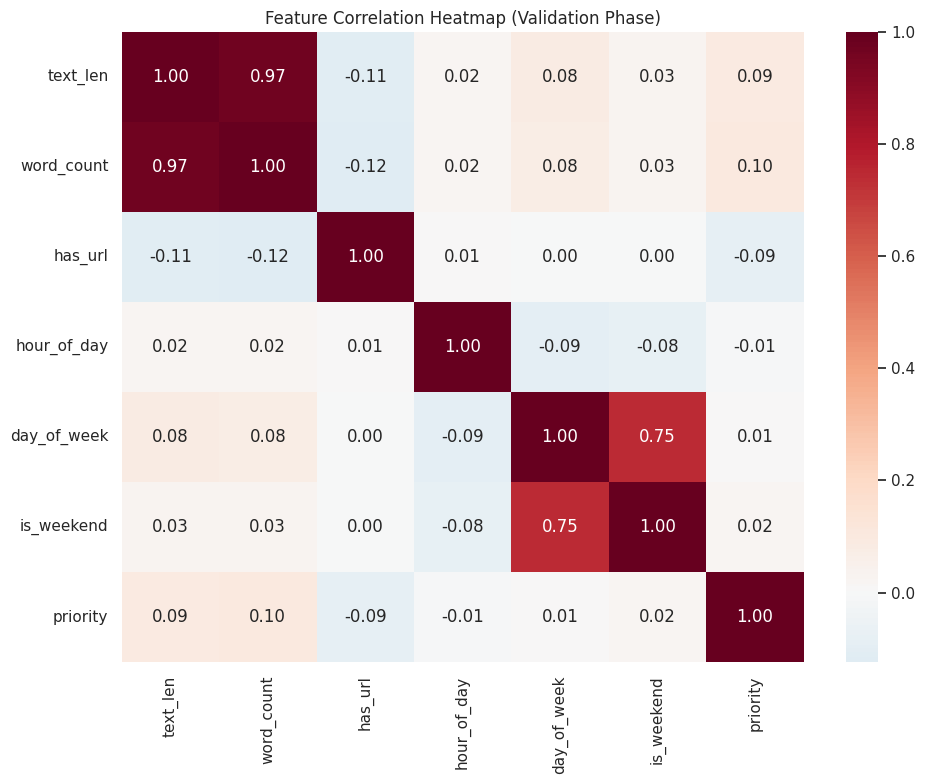

Correlation with Priority:
priority       1.000000
word_count     0.096017
text_len       0.088459
is_weekend     0.019246
day_of_week    0.007533
hour_of_day   -0.008935
has_url       -0.093360
Name: priority, dtype: float64


In [19]:
# --- Final Feature Validation ---

# Select numeric features for correlation
features_to_correlate = [
    'text_len', 'word_count', 'has_url', 
    'hour_of_day', 'day_of_week', 'is_weekend', 'priority'
]

corr_matrix = tickets_df[features_to_correlate].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title("Feature Correlation Heatmap (Validation Phase)")

# Save the final artifact before commit
plt.tight_layout()
plt.savefig(GRAPHS_DIR / "final_correlation_heatmap.png")
plt.show()

# Print the specific correlation with our target
print("Correlation with Priority:")
print(corr_matrix['priority'].sort_values(ascending=False))